In [1]:
import os
os.chdir("/mnt/data/users/XXXX/lab/associative-recurrent-memory-transformer")

from transformers import MambaForCausalLM
import torch

model = MambaForCausalLM.from_pretrained("state-spaces/mamba-1.4b-hf").to("cuda:0")


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [2]:
inputs=dict(
    input_ids=torch.randint(0, 10000, (1, 16384 * 2)).to("cuda:0"),  
    pad_token_id=-100,
    max_new_tokens=1,
)

In [3]:
output = model.generate(**inputs,)


The following generation flags are not valid and may be ignored: ['pad_token_id']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


In [4]:
import torch
from time import time

def get_time(model, seq_len):
    model.eval()
    model.to("cuda:0")
    inputs=dict(
        input_ids=torch.randint(0, 10000, (1, seq_len)).to("cuda:0"),   
        attention_mask=torch.ones(1, seq_len).to("cuda:0"),
        max_new_tokens=1,
    )
    start_time = time()
    model.generate(**inputs)
    end_time = time()   
    return end_time - start_time

In [5]:
import matplotlib.pyplot as plt


times = []
seq_lens = [4096, 8192, 16384, 32768, 65536]
for seq_len in seq_lens:
    cur_time = get_time(model, seq_len)
    times.append(cur_time)


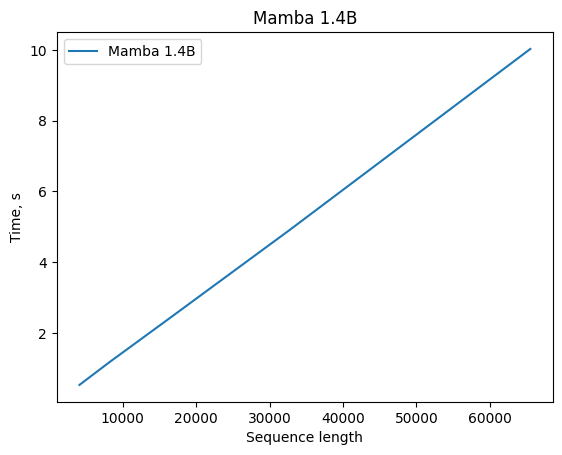

In [6]:

plt.plot(seq_lens, times, label='Mamba 1.4B')
plt.xlabel('Sequence length')
plt.ylabel('Time, s')
plt.title('Mamba 1.4B')
plt.legend()
plt.show()